In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning:
#### Remove duplicates, handle missing reviews if any, preprocess text (lowercasing, stopwords removal).

In [4]:
import pandas as pd

df = pd.read_csv("amazonreviews (1).tsv", sep='\t')

In [5]:
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [7]:
df.shape

(10000, 2)

In [8]:
df.isnull().sum()

label     0
review    0
dtype: int64

No missing values.
 Proper labels (pos, neg).
 Balanced structure (2 columns only — simple).
 Clean dataset → no heavy preprocessing needed.

In [9]:
df['label'].value_counts()

label
neg    5097
pos    4903
Name: count, dtype: int64

The data is balanced

In [11]:
df.columns

Index(['label', 'review'], dtype='object')

# Exploratory Analysis:
### Word clouds, sentiment distribution, most common positive/negative words.

In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(preprocess)

[nltk_data] Downloading package stopwords to C:\Users\DONGRI
[nltk_data]     ASHMANJUM\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [14]:
df.columns

Index(['label', 'review', 'cleaned_review'], dtype='object')

In [15]:
df[['review','cleaned_review']].head()

,review,cleaned_review
0,Stuning even for the non-gamer: This sound tra...,stune even non gamer sound track beauti paint ...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anyth read lot review say...
2,Amazing!: This soundtrack is my favorite music...,amaz soundtrack favorit music time hand intens...
3,Excellent Soundtrack: I truly like this soundt...,excel soundtrack truli like soundtrack enjoy v...
4,"Remember, Pull Your Jaw Off The Floor After He...",rememb pull jaw floor hear play game know divi...


In this step, I performed text preprocessing by converting text to lowercase, removing special characters, removing stopwords, and applying stemming to reduce words to their root form.

# EDA
### sentiment distribution

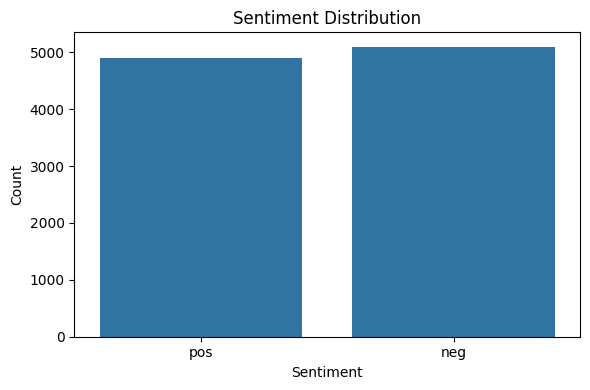

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

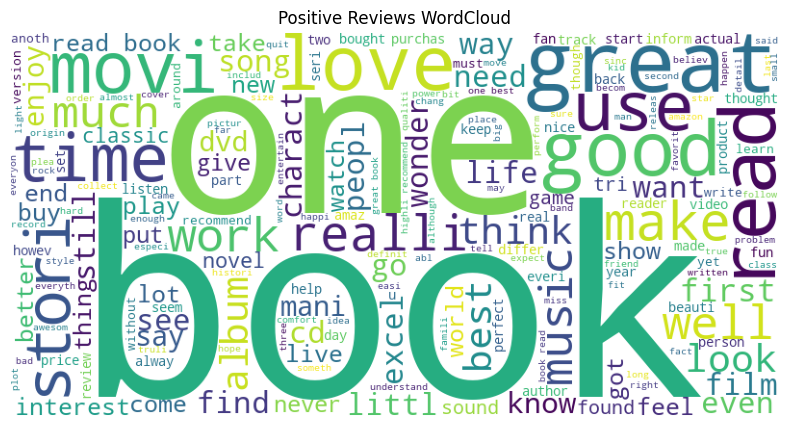

In [21]:
# word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df[df['label']=='pos']['cleaned_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title("Positive Reviews WordCloud")
plt.show()

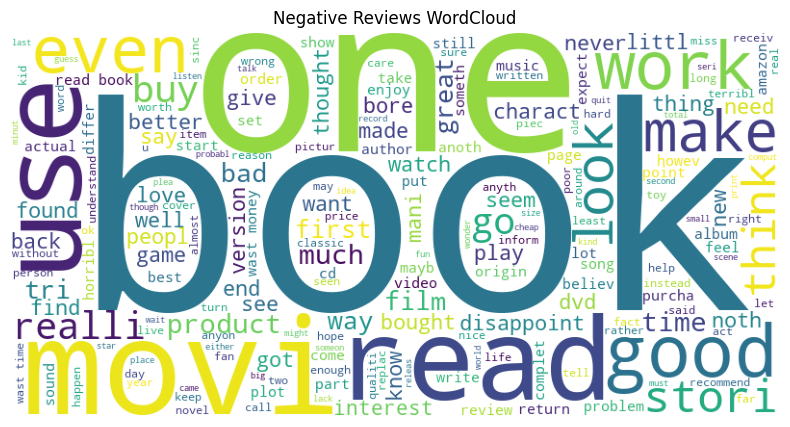

In [22]:
negative_text = " ".join(df[df['label']=='neg']['cleaned_review'])

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis('off')
plt.title("Negative Reviews WordCloud")
plt.show()

EDA helps understand the distribution and key patterns in the data. Word clouds highlight frequently used words in positive and negative reviews.

# Model Development: 
### Use NLP techniques (TF-IDF, Word2Vec, or BERT embeddings) with models like Logistic Regression, SVM, or Neural Networks.

In [23]:
# Feature Extraction
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_review']).toarray()
y = df['label']

In [24]:
X.shape

(10000, 5000)

# Validation: 
### Use train/test split, cross-validation, and metrics like accuracy, F1-score.

In [25]:
# splitting for training and texting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
X_train.shape


(8000, 5000)

In [28]:
X_test.shape

(2000, 5000)

In [29]:
# Model training (Logistic Regression)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
# prediction
y_pred = model.predict(X_test)

In [32]:
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

Accuracy: 0.853
              precision    recall  f1-score   support

         neg       0.86      0.86      0.86      1037
         pos       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

[[890 147]
 [147 816]]


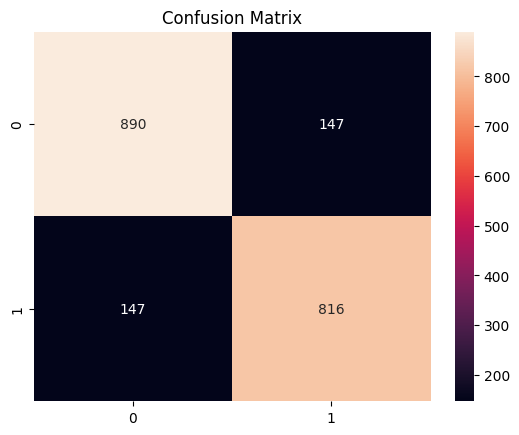

In [33]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

The model achieved an accuracy of 85.3% with balanced precision and recall for both classes. The confusion matrix shows that the model performs equally well on positive and negative reviews, indicating no bias

In [34]:
# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross-validation scores: [0.85   0.825  0.817  0.8305 0.8535]
Mean CV Score: 0.8352


Cross-validation was performed using 5 folds. The mean accuracy of 83.52% confirms that the model is stable and generalizes well, with no signs of overfitting

In [36]:
# SVM model
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))



SVM Accuracy: 0.838
              precision    recall  f1-score   support

         neg       0.85      0.84      0.84      1037
         pos       0.83      0.84      0.83       963

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



Logistic Regression achieved higher accuracy (85.3%) compared to SVM (83.8%), making it the preferred model for this task.